In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
import cartopy.crs as ccrs

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)


In [4]:
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_toa_global.nc'
ds = xr.open_dataset(fp).rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'}).drop_vars('expver')

#interpolate to masks grid
ds = ds.interp(lat=masks.lat, lon=masks.lon)


In [6]:
#ds = ds.where((ds.lat>20) | (ds.lat<-20), drop=True)
ds = ds.where(masks.seamask == 1, drop=True)

In [7]:
#convert J/m2 to W/m2
ds = ds / (24*60*60)

In [8]:
weights = np.cos(np.deg2rad(ds.lat))

#extract variable toa_net_all_mon
ds['tnet'] = ds.tsr + ds.ttr
toa = ds.tnet
#compute anomaly
toa = toa.groupby('time.month') - toa.groupby('time.month').mean('time')

#exract april-september
toa = toa.where((toa['time.month'] >= 4) & (toa['time.month'] <= 9), drop=True).groupby('time.year').mean('time')

#compute difference
dtoa = toa - toa.shift(year=1)

In [7]:
bs = dtoa.where(dtoa.year.isin([1982, 1987, 1991, 1997, 2009, 2015]), drop=True)

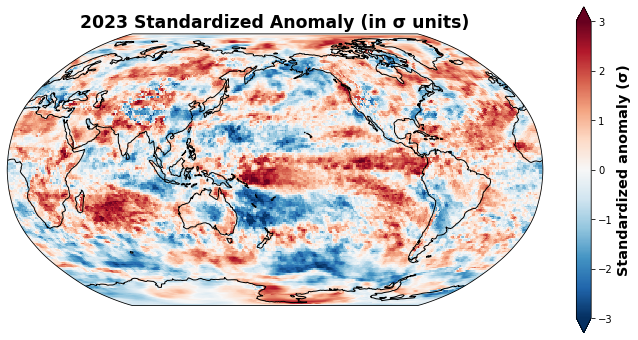

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Compute climatology (mean and std across all years)
mean = dtoa.mean(dim='year')
std = dtoa.std(dim='year')

# Compute standardized anomaly (Z-score) for 2023
zscore = (dtoa.sel(year=2023) - mean) / std

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
zscore.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-3, vmax=3,
                       cbar_kwargs={'label': 'Standardized anomaly (σ)'})
ax.coastlines()
plt.title("2023 Standardized Anomaly (in σ units)")
plt.show()


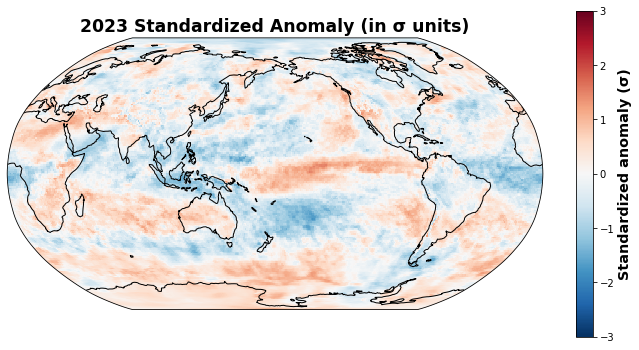

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Compute climatology (mean and std across all years)
mean = dtoa.mean(dim='year')
std = dtoa.std(dim='year')

# Compute standardized anomaly (Z-score) for 2023
zscore = (bs.mean('year') - mean) / std

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
zscore.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-3, vmax=3,
                       cbar_kwargs={'label': 'Standardized anomaly (σ)'})
ax.coastlines()
plt.title("2023 Standardized Anomaly (in σ units)")
plt.show()


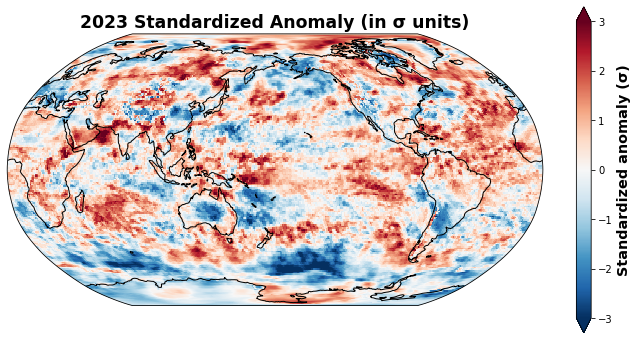

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Compute climatology (mean and std across all years)
mean = dtoa.mean(dim='year')
std = dtoa.std(dim='year')

# Compute standardized anomaly (Z-score) for 2023
zscore = (bs.mean('year') - mean) / std

zscore = (dtoa.sel(year=2023) - mean) / std - zscore

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
zscore.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-3, vmax=3,
                       cbar_kwargs={'label': 'Standardized anomaly (σ)'})
ax.coastlines()
plt.title("2023 Standardized Anomaly (in σ units)")
plt.show()


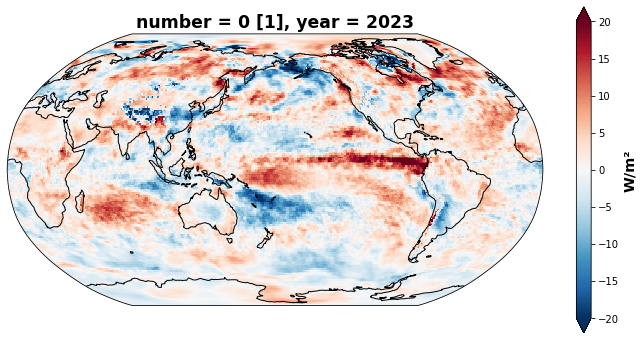

In [11]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
a = dtoa.sel(year=2023)
a.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin = -20, vmax = 20, cbar_kwargs={'label': 'W/m²'})
ax.coastlines()


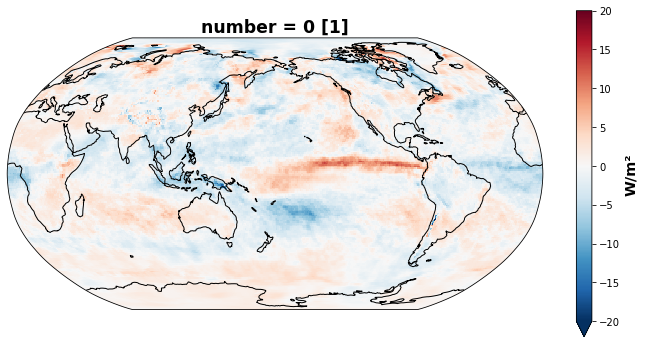

In [12]:
l= [1982, 1987, 1991, 1997, 2009, 2015]
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
k = dtoa.where(dtoa.year.isin(l), drop=True).mean('year')
k.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-20, vmax=20, cbar_kwargs={'label': 'W/m²'})
ax.coastlines()
plt.show()

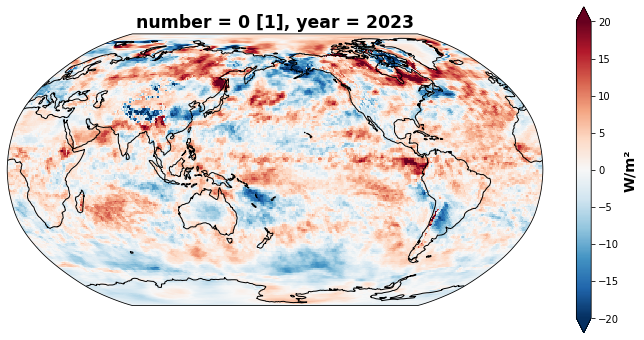

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, figsize=(12,6))
(a-k).plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-20, vmax=20, cbar_kwargs={'label': 'W/m²'})
ax.coastlines()
plt.show()

In [9]:
dn_mean = dtoa.sel(lat = slice(-20, 20)).weighted(weights).mean(('lat', 'lon'))

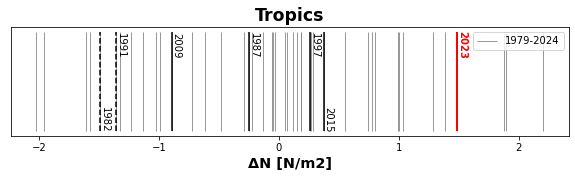

In [10]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Tropics")

plt.legend()


In [11]:
dn_mean = dtoa.sel(lat = slice(-60, -20)).weighted(weights).mean(('lat', 'lon'))

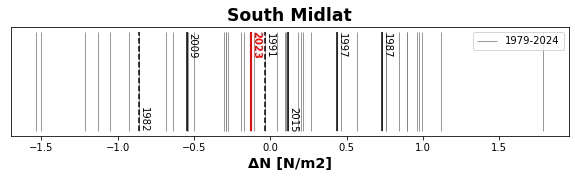

In [12]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("South Midlat")

plt.legend()


In [13]:
dn_mean = dtoa.sel(lat = slice(20, 60)).weighted(weights).mean(('lat', 'lon'))

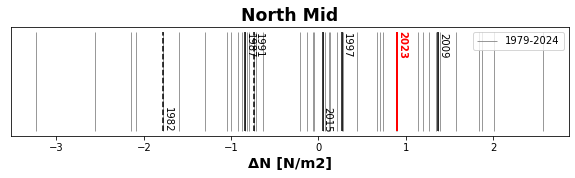

In [14]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("North Mid")

plt.legend()


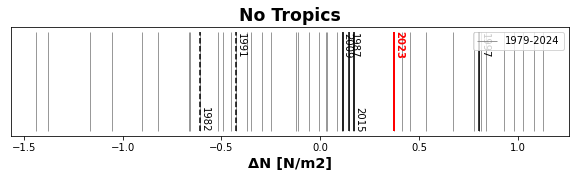

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("No Tropics")

plt.legend()


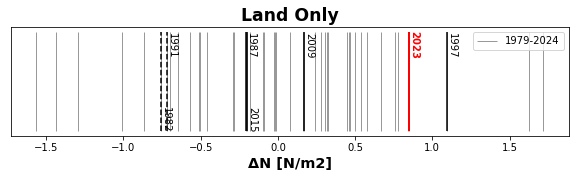

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Land Only")

plt.legend()


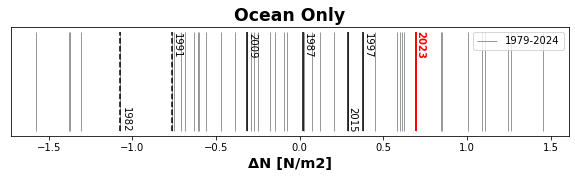

In [ ]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Ocean Only")

plt.legend()


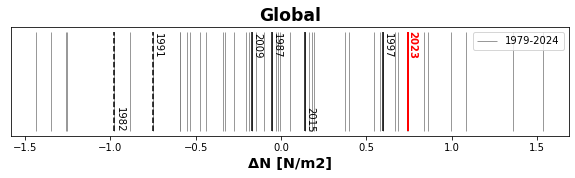

In [15]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991), ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009), ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015), ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y)
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023)
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [N/m2]")
ax.set_title("Global")

plt.legend()
